In [30]:
from ultralytics import YOLO

In [31]:
model = YOLO("best.pt")
#model = YOLO("./models/yolo26n.pt")

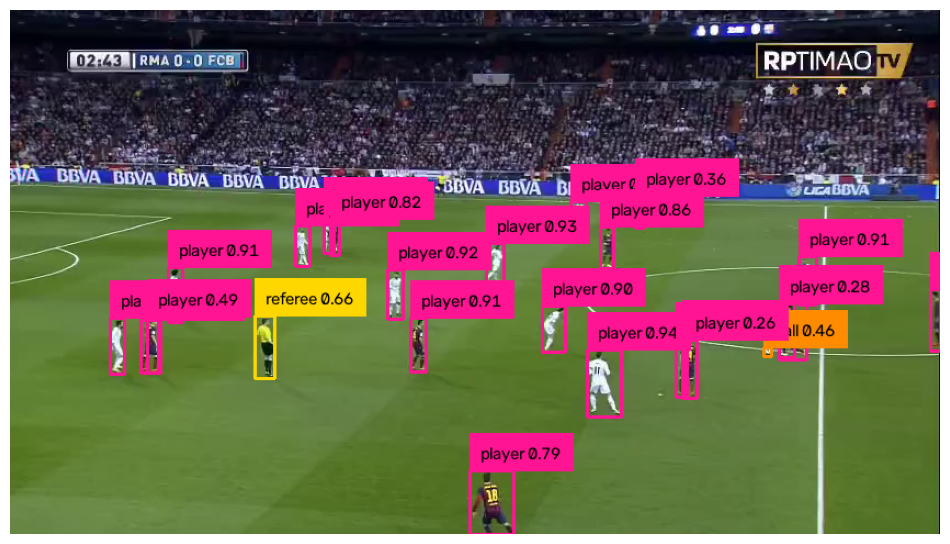

In [32]:
import supervision as sv

box_annotator = sv.BoxAnnotator(
    color=sv.ColorPalette.from_hex(['#FF8C00', '#00BFFF', '#FF1493', '#FFD700']),
    thickness=2,
)

label_annotator = sv.LabelAnnotator(
    color=sv.ColorPalette.from_hex(['#FF8C00', '#00BFFF', '#FF1493', '#FFD700']),
    text_color=sv.Color.from_hex('#000000')
)


SOURCE_VIDEO_PATH = "./vid.mp4"

frame_generator = sv.get_video_frames_generator(SOURCE_VIDEO_PATH)
frame = next(frame_generator)

results = model(frame, imgsz=640, verbose=False)
results = results[0]

#detections = sv.Detections.from_inference(results)

detections = sv.Detections(
    xyxy=results.boxes.xyxy.cpu().numpy(),
    confidence=results.boxes.conf.cpu().numpy(),
    class_id=results.boxes.cls.cpu().numpy().astype(int)
)

labels = [
    f"{model.names[int(class_id)]} {confidence:.2f}"
    for class_id, confidence
    in zip(
        detections.class_id, detections.confidence
        )
]


annotated_frame = frame.copy()
annotated_frame = box_annotator.annotate(annotated_frame,detections)
annotated_frame = label_annotator.annotate(annotated_frame,detections,labels=labels)

sv.plot_image(annotated_frame)

In [33]:
import supervision as sv
from tqdm import tqdm

box_annotator = sv.BoxAnnotator(
    color=sv.ColorPalette.from_hex(['#FF8C00', '#00BFFF', '#FF1493', '#FFD700']),
    thickness=2,
)

label_annotator = sv.LabelAnnotator(
    color=sv.ColorPalette.from_hex(['#FF8C00', '#00BFFF', '#FF1493', '#FFD700']),
    text_color=sv.Color.from_hex('#000000')
)


SOURCE_VIDEO_PATH = "./vid.mp4"
TARGET_VIDEO_PATH = "./vid_result.mp4"

video_info = sv.VideoInfo.from_video_path(SOURCE_VIDEO_PATH)
video_sink = sv.VideoSink(TARGET_VIDEO_PATH,video_info=video_info)

frame_generator = sv.get_video_frames_generator(SOURCE_VIDEO_PATH)

with video_sink:
    for frame in tqdm(frame_generator,total=video_info.total_frames):


        results = model(frame, imgsz=1280, verbose=False)
        results = results[0]

        #detections = sv.Detections.from_inference(results)

        detections = sv.Detections(
            xyxy=results.boxes.xyxy.cpu().numpy(),
            confidence=results.boxes.conf.cpu().numpy(),
            class_id=results.boxes.cls.cpu().numpy().astype(int)
        )

        labels = [
            f"{model.names[int(class_id)]} {confidence:.2f}"
            for class_id, confidence
            in zip(
                detections.class_id, detections.confidence
                )
        ]


        annotated_frame = frame.copy()
        annotated_frame = box_annotator.annotate(annotated_frame,detections)
        annotated_frame = label_annotator.annotate(annotated_frame,detections,labels=labels)
        video_sink.write_frame(annotated_frame)

#sv.plot_image(annotated_frame)

100%|██████████| 1752/1752 [02:31<00:00, 11.56it/s]


In [ ]:
import supervision as sv
from tqdm import tqdm

ellipse_annotator = sv.EllipseAnnotator(
    color=sv.ColorPalette.from_hex(['#FF8C00', '#00BFFF', '#FF1493', '#FFD700']),
    thickness=2,
)

""" label_annotator = sv.LabelAnnotator(
    color=sv.ColorPalette.from_hex(['#FF8C00', '#00BFFF', '#FF1493', '#FFD700']),
    text_color=sv.Color.from_hex('#000000')
) """

triangle_annotator = sv.TriangleAnnotator(
    color=sv.Color.from_hex("#FFC700"),
    base=25,
    height=21,
    outline_thickness=1
)


SOURCE_VIDEO_PATH = "./vid.mp4"
TARGET_VIDEO_PATH = "./vid_result.mp4"

video_info = sv.VideoInfo.from_video_path(SOURCE_VIDEO_PATH)
video_sink = sv.VideoSink(TARGET_VIDEO_PATH,video_info=video_info)

frame_generator = sv.get_video_frames_generator(SOURCE_VIDEO_PATH)

with video_sink:
    for frame in tqdm(frame_generator,total=video_info.total_frames):


        results = model(frame, imgsz=640, verbose=False)
        results = results[0]

        ball_detections = detections[detections.class_id == 0]
        all_detections = detections[detections.class_id != 0]

        #detections = sv.Detections.from_inference(results)

        detections = sv.Detections(
            xyxy=results.boxes.xyxy.cpu().numpy(),
            confidence=results.boxes.conf.cpu().numpy(),
            class_id=results.boxes.cls.cpu().numpy().astype(int)
        )

        """ labels = [
            f"{model.names[int(class_id)]} {confidence:.2f}"
            for class_id, confidence
            in zip(
                detections.class_id, detections.confidence
                )
        ] """


        annotated_frame = frame.copy()
        annotated_frame = ellipse_annotator.annotate(annotated_frame,all_detections)
        annotated_frame = triangle_annotator.annotate(annotated_frame,ball_detections)
        video_sink.write_frame(annotated_frame)


 79%|███████▉  | 1389/1752 [01:14<00:24, 14.53it/s]

In [ ]:
import supervision as sv
from tqdm import tqdm

ellipse_annotator = sv.EllipseAnnotator(
    color=sv.ColorPalette.from_hex(['#00BFFF', '#FF1493', '#FFD700']),
    thickness=2,
)

""" label_annotator = sv.LabelAnnotator(
    color=sv.ColorPalette.from_hex(['#FF8C00', '#00BFFF', '#FF1493', '#FFD700']),
    text_color=sv.Color.from_hex('#000000')
) """

triangle_annotator = sv.TriangleAnnotator(
    color=sv.Color.from_hex("#FFC700"),
    base=25,
    height=21,
    outline_thickness=1
)


SOURCE_VIDEO_PATH = "./vid.mp4"
TARGET_VIDEO_PATH = "./vid_result.mp4"

video_info = sv.VideoInfo.from_video_path(SOURCE_VIDEO_PATH)
video_sink = sv.VideoSink(TARGET_VIDEO_PATH,video_info=video_info)

frame_generator = sv.get_video_frames_generator(SOURCE_VIDEO_PATH)

with video_sink:
    for frame in tqdm(frame_generator,total=video_info.total_frames):


        results = model(frame, imgsz=640, verbose=False)
        results = results[0]

        detections = sv.Detections(
            xyxy=results.boxes.xyxy.cpu().numpy(),
            confidence=results.boxes.conf.cpu().numpy(),
            class_id=results.boxes.cls.cpu().numpy().astype(int)
        )
        ball_detections = detections[detections.class_id == 0]
        all_detections = detections[detections.class_id != 0]
        
        all_detections = all_detections.with_nms(threshold=0.5,class_agnostic=True)
        all_detections.class_id = all_detections.class_id - 1

        """ labels = [
            f"{model.names[int(class_id)]} {confidence:.2f}"
            for class_id, confidence
            in zip(
                detections.class_id, detections.confidence
                )
        ] """


        annotated_frame = frame.copy()
        annotated_frame = ellipse_annotator.annotate(annotated_frame,all_detections)
        annotated_frame = triangle_annotator.annotate(annotated_frame,ball_detections)
        video_sink.write_frame(annotated_frame)


100%|██████████| 1752/1752 [00:47<00:00, 36.74it/s]


In [ ]:
import supervision as sv
from tqdm import tqdm

model = YOLO("yolo26l.pt")

ellipse_annotator = sv.EllipseAnnotator(
    color=sv.ColorPalette.from_hex(['#00BFFF', '#FF1493', '#FFD700']),
    thickness=2,
)

label_annotator = sv.LabelAnnotator(
    color=sv.ColorPalette.from_hex(['#00BFFF', '#FF1493', '#FFD700']),
    text_color=sv.Color.from_hex('#000000'),
    text_position=sv.Position.BOTTOM_CENTER
)


triangle_annotator = sv.TriangleAnnotator(
    color=sv.Color.from_hex("#FFC700"),
    base=25,
    height=21,
    outline_thickness=1
)


SOURCE_VIDEO_PATH = "./newvid.mp4"
TARGET_VIDEO_PATH = "./vid_result.mp4"

video_info = sv.VideoInfo.from_video_path(SOURCE_VIDEO_PATH)
video_sink = sv.VideoSink(TARGET_VIDEO_PATH,video_info=video_info)

frame_generator = sv.get_video_frames_generator(SOURCE_VIDEO_PATH)

tracker = sv.ByteTrack()
#tracker.reset()

with video_sink:
    for frame in tqdm(frame_generator,total=video_info.total_frames):


        results = model(frame, imgsz=1280, verbose=False)
        results = results[0]


        detections = sv.Detections(
                    xyxy=results.boxes.xyxy.cpu().numpy(),
                    confidence=results.boxes.conf.cpu().numpy(),
                    class_id=results.boxes.cls.cpu().numpy().astype(int)
                )

        ball_detections = detections[detections.class_id == 32]
        all_detections = detections[detections.class_id != 32]

        all_detections = all_detections.with_nms(threshold=0.2,class_agnostic=True)
        #all_detections.class_id = all_detesmb://smb:
        all_detections = tracker.update_with_detections(all_detections)



        labels = [
            f"#{tracker_id}"
            for tracker_id in all_detections.tracker_id
        ]


        annotated_frame = frame.copy()
        annotated_frame = ellipse_annotator.annotate(annotated_frame,all_detections)
        annotated_frame = triangle_annotator.annotate(annotated_frame,ball_detections)
        annotated_frame = label_annotator.annotate(annotated_frame,all_detections,labels=labels)
        video_sink.write_frame(annotated_frame)


C:\Users\Muhammed Rafi\AppData\Local\Temp\ipykernel_14572\2975344799.py:34: FutureWarning: The `ByteTrack` was deprecated since v0.28.0. It will be removed in v0.31.0.
  tracker = sv.ByteTrack()
100%|██████████| 534/534 [00:48<00:00, 11.10it/s]


In [5]:
from tqdm import tqdm

SOURCE_VIDEO_PATH=r"C:\Users\Muhammed Rafi\OneDrive\Documents\rafi_football_yolo\vid.mp4"

frame_generator = sv.get_video_frames_generator(source_path=SOURCE_VIDEO_PATH,stride=30)

crops=[]

for frame in tqdm(frame_generator,desc="cropping"):
    pass

cropping: 59it [00:00, 74.40it/s]


In [1]:
def cropper(results):        
    detections = sv.Detections.from_ultralytics(results)
    players = detections[detections.class_id == 0]
    for xyxy in players.xyxy:
        crops.append(sv.crop_image(image=frame,xyxy=xyxy))
    return crops

In [2]:
import supervision as sv
from tqdm import tqdm
from ultralytics import YOLO

SOURCE_VIDEO_PATH = "./vid.mp4"


#model = YOLO("yolo26l.pt")

def cropper(source_video_path):
    frame_generator = sv.get_video_frames_generator(source_path=SOURCE_VIDEO_PATH,stride=30)

    crops=[]

    for frame in tqdm(frame_generator,desc="cropping"):
        results = model(frame,imgsz=1280, verbose=False)
        results=results[0]

        detections = sv.Detections.from_ultralytics(results)

        """ detections=sv.Detections(
            xyxy=results.boxes.xyxy.cpu().numpy(),
            class_id=results.boxes.cls.cpu().numpy().astype(int)
            
        ) """
        players = detections[detections.class_id == 2]
        for xyxy in players.xyxy:
            crops.append(sv.crop_image(image=frame,xyxy=xyxy))
    return crops

In [6]:
crp = cropper(SOURCE_VIDEO_PATH)

cropping: 59it [00:05, 10.27it/s]


In [ ]:
import matplotlib.pyplot as plt
import cv2

plt.figure(figsize=(5, 5))
for i in range(10):
    plt.imshow(cv2.cvtColor(crp[i], cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.show()

In [9]:
import numpy as np
import sklearn
import cv2
from sklearn.cluster import KMeans

def extract_jersey_color(crop):
    """
    Slices the upper torso (approx. 20% to 50% height, 20% to 80% width)
    to ignore the head/hair, shorts, socks, and background pitch.
    """
    h, w, _ = crop.shape
    if h == 0 or w == 0:
        return np.zeros(3)
        
    torso = crop[int(h * 0.2):int(h * 0.5), int(w * 0.2):int(w * 0.8)]
    
    # Optional: Convert BGR to HSV or LAB for better color invariance
    # torso_hsv = cv2.cvtColor(torso, cv2.COLOR_BGR2HSV)
    
    # Calculate the median color of the torso
    median_color = np.median(torso.reshape(-1, 3), axis=0)
    return median_color

# 1. Collect torso color features for your dataset of crops
features = np.array([extract_jersey_color(crop) for crop in crp if crop.size > 0])

# 2. Fit KMeans with 2 clusters (Team 0 vs Team 1)
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
team_labels = kmeans.fit_predict(features)

In [10]:
def predict_team(crop,kmeans_model):
    if crop is None or crop.size == 0:
        return 0
    feat = extract_jersey_color(crop).reshape(1,-1)
    return int(kmeans_model.predict(feat)[0])

In [ ]:
from ultralytics import YOLO

#model = YOLO("./yolov26m-football.pt")
print(model.names)

{0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 58: 'potted plant', 59: 'bed', 60: 'dining table', 61: 'toilet', 62: 'tv', 63: 'laptop', 64: 'mouse', 65: 'remote', 66: 'keyboard', 67: 'cell phone', 68: 'microw

In [ ]:
import supervision as sv
from tqdm import tqdm
from ultralytics import YOLO
import sklearn
import cv2
from sklearn.cluster import KMeans
import numpy as np
model=YOLO("yolo26x.pt")
tracker = sv.ByteTrack()

SOURCE_VIDEO_PATH="./newvid.mp4"
TARGET_VIDEO_PATH="./vid_result.mp4"
video_info = sv.VideoInfo.from_video_path(SOURCE_VIDEO_PATH)
video_sink = sv.VideoSink(TARGET_VIDEO_PATH, video_info=video_info)
frame_generator = sv.get_video_frames_generator(SOURCE_VIDEO_PATH, stride=1)
training_crops = []

TEAM_PALETTE = sv.ColorPalette.from_hex(["#FFDD00", "#AB1163"])
ellipse_annotator = sv.EllipseAnnotator(
color=TEAM_PALETTE,
thickness=2
)
label_annotator = sv.LabelAnnotator(
color=TEAM_PALETTE,
text_color=sv.Color.from_hex('#FFFFFF'),
text_position=sv.Position.BOTTOM_CENTER
)
ball_annotator = sv.TriangleAnnotator(
color=sv.Color.from_hex('#FFD700'),
base=25,
height=21,
outline_thickness=1
)

tracker_team_memory = {}

with video_sink:
    for frame in tqdm(frame_generator,total=video_info.total_frames):

        results = model(frame, imgsz=1280, verbose=False)
        results = results[0]
        detections = sv.Detections.from_ultralytics(results)
        """ detections = sv.Detections(
                    xyxy=results.boxes.xyxy.cpu().numpy(),
                    confidence=results.boxes.conf.cpu().numpy(),
                    class_id=results.boxes.cls.cpu().numpy().astype(int)
                ) """

        ball_detections = detections[detections.class_id == 32]
        all_detections = detections[detections.class_id != 32]
        all_detections = all_detections.with_nms(threshold=0.1, class_agnostic=True)
        all_detections = tracker.update_with_detections(all_detections)
        players = all_detections[all_detections.class_id == 0]
        team_id = []
        if len(players) > 0:
            for xyxy, track_id in zip(players.xyxy, players.tracker_id):
                if track_id in tracker_team_memory:
                    team_id.append(tracker_team_memory[track_id])
                else:
                    crop = sv.crop_image(image=frame, xyxy=xyxy)
                    team = predict_team(crop, kmeans)
                    tracker_team_memory[track_id] = team
                    team_id.append(team)


        labels = [
            f"Team {team + 1} #{track_id}"
            for team, track_id in zip(team_id, players.tracker_id)
        ]

        players.class_id = np.array(team_id)

        annotated_frame = frame.copy()
        annotated_frame = ellipse_annotator.annotate(scene=annotated_frame, detections=players)
        annotated_frame = label_annotator.annotate(scene=annotated_frame, detections=players, labels=labels)
        annotated_frame = ball_annotator.annotate(scene=annotated_frame, detections=ball_detections)

        video_sink.write_frame(annotated_frame)

print(f"Output saved to: {TARGET_VIDEO_PATH}")


""" features = np.array(extract_jersey_color(crop) for crop in training_crops)
kmeans = KMeans(n_clusters=2,random_state=42,n_init=10)
kmeans.fit(features) """


100%|██████████| 534/534 [00:55<00:00,  9.55it/s]

Output saved to: ./vid_result.mp4


' features = np.array(extract_jersey_color(crop) for crop in training_crops)\nkmeans = KMeans(n_clusters=2,random_state=42,n_init=10)\nkmeans.fit(features) '

In [11]:
import supervision as sv
from tqdm import tqdm
from ultralytics import YOLO
import sklearn
import cv2
from sklearn.cluster import KMeans
import numpy as np
model=YOLO("best_model.pt")
tracker = sv.ByteTrack()

SOURCE_VIDEO_PATH="./ftt.mp4"
TARGET_VIDEO_PATH="./vid_result.mp4"
video_info = sv.VideoInfo.from_video_path(SOURCE_VIDEO_PATH)
video_sink = sv.VideoSink(TARGET_VIDEO_PATH, video_info=video_info)
frame_generator = sv.get_video_frames_generator(SOURCE_VIDEO_PATH, stride=1)
training_crops = []

TEAM_PALETTE = sv.ColorPalette.from_hex(["#FFDD00", "#AB1163"])
GOALKEEPER_PALETTE = sv.ColorPalette.from_hex(["#020AFF", "#05FF01"])
REFEREE_PALETTE = sv.ColorPalette.from_hex(["#000000"])

player_ellipse_annotator = sv.EllipseAnnotator(color=TEAM_PALETTE, thickness=2)
player_label_annotator = sv.LabelAnnotator(
    color=TEAM_PALETTE,
    text_color=sv.Color.from_hex("#FFFFFF"),
    text_position=sv.Position.BOTTOM_CENTER,
    text_scale=0.4,
    text_thickness=1,
    text_padding=3
)

gk_ellipse_annotator = sv.EllipseAnnotator(color=GOALKEEPER_PALETTE, thickness=2)
gk_label_annotator = sv.LabelAnnotator(
    color=GOALKEEPER_PALETTE,
    text_color=sv.Color.from_hex("#FFFFFF"),
    text_position=sv.Position.BOTTOM_CENTER,
    text_scale=0.4,
    text_thickness=1,
    text_padding=3
)

ref_ellipse_annotator = sv.EllipseAnnotator(color=REFEREE_PALETTE, thickness=2)
ref_label_annotator = sv.LabelAnnotator(
    color=REFEREE_PALETTE,
    text_color=sv.Color.from_hex("#FFFFFF"),
    text_position=sv.Position.BOTTOM_CENTER
)

ball_annotator = sv.TriangleAnnotator(
color=sv.Color.from_hex('#FFD700'),
base=25,
height=21,
outline_thickness=1
)

tracker_team_memory = {}

with video_sink:
    for frame in tqdm(frame_generator,total=video_info.total_frames):

        results = model(frame, imgsz=1280, verbose=False)
        results = results[0]
        detections = sv.Detections.from_ultralytics(results)

        ball_detections = detections[detections.class_id == 0]

        all_detections = detections[detections.class_id != 0]
        all_detections = all_detections.with_nms(threshold=0.4, class_agnostic=True)
        all_detections = tracker.update_with_detections(all_detections)

        players = all_detections[all_detections.class_id == 2]
        goalkeeper = all_detections[all_detections.class_id == 1]
        referee = all_detections[all_detections.class_id == 3]

        annotated_frame = frame.copy()

        if len(players) > 0:
            team_id = []
            for xyxy, track_id in zip(players.xyxy, players.tracker_id):
                if track_id in tracker_team_memory:
                    team_id.append(tracker_team_memory[track_id])
                else:
                    crop = sv.crop_image(image=frame, xyxy=xyxy)
                    team = predict_team(crop, kmeans)
                    tracker_team_memory[track_id] = team
                    team_id.append(team)
            players.class_id = np.array(team_id)

            labels = [
                f"Team {team + 1} #{track_id}"
                for team, track_id in zip(team_id, players.tracker_id)
            ]
            annotated_frame = player_ellipse_annotator.annotate(scene=annotated_frame, detections=players)
            annotated_frame = player_label_annotator.annotate(scene=annotated_frame, detections=players, labels=labels)

        if len(goalkeeper) > 0:
            gk_labels = [f"GK #{track_id}" for track_id in goalkeeper.tracker_id]
            annotated_frame = gk_ellipse_annotator.annotate(
                scene=annotated_frame, detections=goalkeeper
            )
            annotated_frame = gk_label_annotator.annotate(
                scene=annotated_frame, detections=goalkeeper, labels=gk_labels
            )

        if len(referee) > 0:
            ref_labels = [f"Ref #{track_id}" for track_id in referee.tracker_id]
            annotated_frame = ref_ellipse_annotator.annotate(
                scene=annotated_frame, detections=referee
            )
            annotated_frame = ref_label_annotator.annotate(
                scene=annotated_frame, detections=referee, labels=ref_labels
            )
        annotated_frame = ball_annotator.annotate(
            scene=annotated_frame, detections=ball_detections
        )

        video_sink.write_frame(annotated_frame)

print(f"Output saved to: {TARGET_VIDEO_PATH}")


100%|██████████| 910/910 [01:20<00:00, 11.36it/s]

Output saved to: ./vid_result.mp4


In [2]:
print("Model classes:", model.names)

NameError: name 'model' is not defined

FIELD-DETECTION 

SupervisionWarnings: 'KeyPoints.confidence' is deprecated since 0.29.0 and will be removed in 0.32.0. Use 'KeyPoints.keypoint_confidence' instead.


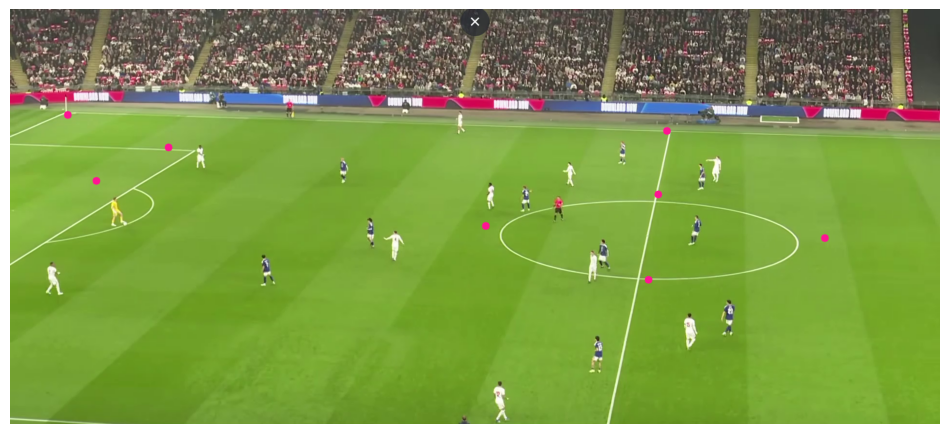

In [11]:
import os
from dotenv import load_dotenv
from inference import get_model
import supervision as sv
import numpy as np

load_dotenv()

ROBOFLOW_API_KEY = os.getenv("ROBOFLOW_API_KEY")
PITCH_DETECTION_MODEL_ID = "football-field-detection-f07vi/14"
PITCH_DETECTION_MODEL = get_model(
    model_id=PITCH_DETECTION_MODEL_ID,
    api_key=ROBOFLOW_API_KEY
)

SOURCE_VIDEO_PATH = "./ftt.mp4"
TARGET_VIDEO_PATH = "./field_keypoints_annotated.mp4"

vertex_annotator = sv.VertexAnnotator(
    color=sv.Color.from_hex("#FF1493"),
    radius=8
)

frame_generator = sv.get_video_frames_generator(SOURCE_VIDEO_PATH)
frame = next(frame_generator)

result = PITCH_DETECTION_MODEL.infer(frame,confidence=0.3)[0]
key_points = sv.KeyPoints.from_inference(result)

filter = key_points.confidence[0] > 0.5
frame_reference_points = key_points.xy[0][filter]
frame_reference_key_points = sv.KeyPoints(xy=frame_reference_points[np.newaxis, ...])


annotated_frame = frame.copy()
annotated_frame = vertex_annotator.annotate(annotated_frame,frame_reference_key_points)

sv.plot_image(annotated_frame)




In [5]:
import os
import numpy as np
import supervision as sv
from dotenv import load_dotenv
from inference import get_model
from tqdm import tqdm

load_dotenv()

ROBOFLOW_API_KEY = os.getenv("ROBOFLOW_API_KEY")
PITCH_DETECTION_MODEL_ID = "football-field-detection-f07vi/14"
PITCH_DETECTION_MODEL = get_model(
    model_id=PITCH_DETECTION_MODEL_ID,
    api_key=ROBOFLOW_API_KEY
)

SOURCE_VIDEO_PATH = "./ftt.mp4"
TARGET_VIDEO_PATH = "./field_keypoints_annotated.mp4"

vertex_annotator = sv.VertexAnnotator(
    color=sv.Color.from_hex("#FF1493"),
    radius=8
)

video_info = sv.VideoInfo.from_video_path(SOURCE_VIDEO_PATH)
frame_generator = sv.get_video_frames_generator(SOURCE_VIDEO_PATH)

with sv.VideoSink(target_path=TARGET_VIDEO_PATH, video_info=video_info) as sink:
    for frame in tqdm(frame_generator, total=video_info.total_frames, desc="Processing Video"):
        result = PITCH_DETECTION_MODEL.infer(frame, confidence=0.3)[0]
        key_points = sv.KeyPoints.from_inference(result)

        annotated_frame = frame.copy()

        if len(key_points) > 0 and key_points.keypoint_confidence is not None:
            mask = key_points.keypoint_confidence[0] > 0.5
            frame_reference_points = key_points.xy[0][mask]

            if len(frame_reference_points) > 0:
                frame_reference_key_points = sv.KeyPoints(
                    xy=frame_reference_points[np.newaxis, ...]
                )
                annotated_frame = vertex_annotator.annotate(
                    scene=annotated_frame,
                    key_points=frame_reference_key_points
                )

        sink.write_frame(annotated_frame)

ModelDependencyMissing: Your `inference` configuration does not support PaliGemma model. Use pip install 'inference[transformers]' to install missing requirements.To suppress this warning, set PALIGEMMA_ENABLED to False.
ModelDependencyMissing: Your `inference` configuration does not support Florence2 model. Use pip install 'inference[transformers]' to install missing requirements.To suppress this warning, set FLORENCE2_ENABLED to False.
ModelDependencyMissing: Your `inference` configuration does not support Qwen2.5-VL model. Use pip install 'inference[transformers]' to install missing requirements.To suppress this warning, set QWEN_2_5_ENABLED to False.
ModelDependencyMissing: Your `inference` configuration does not support Qwen3-VL model. Use pip install 'inference[transformers]' to install missing requirements.To suppress this warning, set QWEN_3_ENABLED to False.
ModelDependencyMissing: Your `inference` configuration does not support SAM model. Use pip install 'inference[sam]' to i

PROJECTION ON FRAME

In [2]:
from sports.configs.soccer import SoccerPitchConfiguration

CONFIG = SoccerPitchConfiguration()

In [3]:
CONFIG.vertices

[(0, 0),
 (0, 1450.0),
 (0, 2584.0),
 (0, 4416.0),
 (0, 5550.0),
 (0, 7000),
 (550, 2584.0),
 (550, 4416.0),
 (1100, 3500.0),
 (2015, 1450.0),
 (2015, 2584.0),
 (2015, 4416.0),
 (2015, 5550.0),
 (6000.0, 0),
 (6000.0, 2585.0),
 (6000.0, 4415.0),
 (6000.0, 7000),
 (9985, 1450.0),
 (9985, 2584.0),
 (9985, 4416.0),
 (9985, 5550.0),
 (10900, 3500.0),
 (11450, 2584.0),
 (11450, 4416.0),
 (12000, 0),
 (12000, 1450.0),
 (12000, 2584.0),
 (12000, 4416.0),
 (12000, 5550.0),
 (12000, 7000),
 (5085.0, 3500.0),
 (6915.0, 3500.0)]

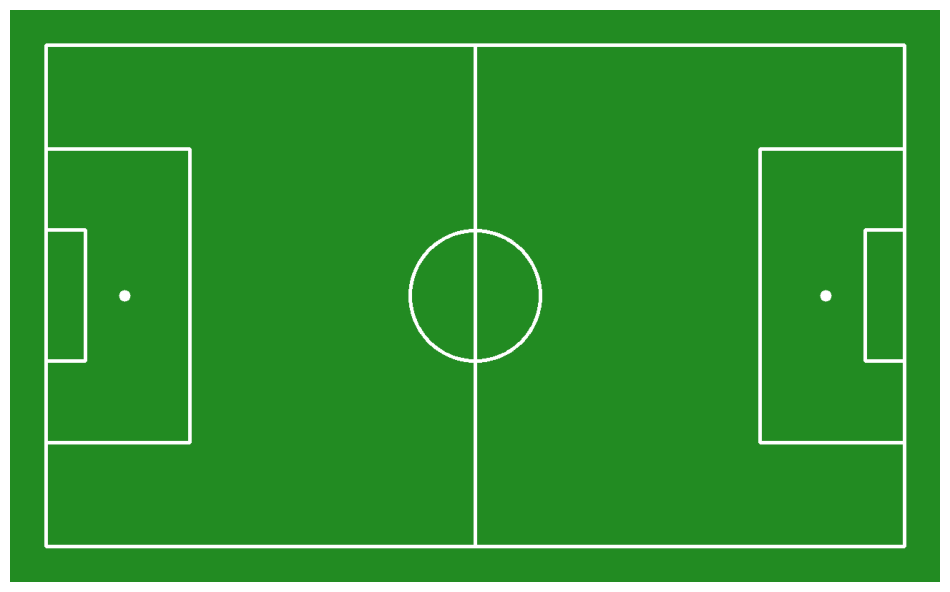

In [6]:
from sports.annotators.soccer import draw_pitch

annotated_frame = draw_pitch(CONFIG)

sv.plot_image(annotated_frame)

In [ ]:
import cv2 

class ViewTransformer:

    def __init__(self,source: np.ndarray, target: np.ndarray):
        source = source.astype(np.float32)
        target = target.astype(np.float32)
        self.m,_ = cv2.findHomography(source,target)
    def transform_points(self,points:np.ndarray) ->np.ndarray:
        points = points.reshape(-1,1,2).astype(np.float32)
        points = cv2.perspectiveTransform(points